# Moresampler semi-auto otoing pipeline

This notebook is for you to just drag your samples in and bam it will help you oto it automatically with any prep like installation or wine etc. It requires a few clicks but you're either here because you are on Unix system and set up is hard, Moresampler is treating you like you're his ex, or you're just lazy, so it's actually quite worth the time.

This notebook is managed by Chz.

[GitHub](https://github.com/hungrierr)

# Setup (it takes around 5 minutes)

In [ ]:
# @title
print("---> Installing Wine ---")
!pip install colab-xterm
import os
import subprocess
import shutil

print("---> Installing Wine ---")
!dpkg --add-architecture i386
!apt update
!apt install -y wine-stable

print("---> Wine installation attempted. ---")


print("\n---> Installing 7zip ---")
!apt install -y p7zip-full
print("---> 7zip installed. ---")


print("\n---> Cloning Moresampler repository ---")
moresampler_repo_path = "/content/moresampler"
if not os.path.exists(moresampler_repo_path):
    !git clone https://github.com/hungrierr/Moresampler {moresampler_repo_path}
    print(f"---> Moresampler cloned to {moresampler_repo_path} ---")
else:
    print(f"---> Moresampler directory already exists at {moresampler_repo_path}. Skipping clone. ---")


print("\n---> Waiting for user input ---")
zip_path = input("Please enter the path to your uploaded zip/7z file (e.g., /content/my_samples.zip)(you can click the three dots next to an uploaded file to get its path; upload your files by draging files into the files tab (refer to the last section)): ")

if not os.path.exists(zip_path):
    print(f"Error: The specified file '{zip_path}' does not exist. Please upload it and provide the correct path.")
else:
    print(f"\n---> Processing '{zip_path}' ---")

    output_dir = "/content/samples"
    os.makedirs(output_dir, exist_ok=True)

    temp_unzip_dir = "/content/temp_unzipped_samples"
    os.makedirs(temp_unzip_dir, exist_ok=True)

    print(f"Extracting '{zip_path}' to '{temp_unzip_dir}'...")
    try:
        subprocess.run(["7z", "x", zip_path, f"-o{temp_unzip_dir}"], check=True, capture_output=True, text=True)
        print("Extraction complete.")
    except subprocess.CalledProcessError as e:
        print(f"Error during 7z extraction: {e}")
        print(f"Stdout: {e.stdout}")
        print(f"Stderr: {e.stderr}")
        print("Skipping audio file filtering due to extraction error.")
        if os.path.exists(temp_unzip_dir):
            shutil.rmtree(temp_unzip_dir)
    else:
        print("Filtering and moving audio files...")
        audio_extensions = (".wav", ".mp3", ".ogg", ".flac", ".aiff", ".m4a", ".opus")
        moved_count = 0
        for root, _, files in os.walk(temp_unzip_dir):
            for file in files:
                src_path = os.path.join(root, file)
                relative_path = os.path.relpath(src_path, temp_unzip_dir)

                if "__MACOSX" in relative_path.split(os.sep):
                    print(f"Skipping macOS metadata file: {relative_path}")
                    continue

                if file.lower().endswith(audio_extensions):
                    dest_path = os.path.join(output_dir, file)

                    base, ext = os.path.splitext(file)
                    counter = 1
                    original_dest_path = dest_path
                    while os.path.exists(dest_path):
                        dest_path = os.path.join(output_dir, f"{base}_{counter}{ext}")
                        counter += 1

                    try:
                        os.rename(src_path, dest_path)
                        moved_count += 1
                    except OSError as e:
                        print(f"Could not move {src_path} to {dest_path}: {e}")

        print(f"Moved {moved_count} audio files to '{output_dir}'.")

        if os.path.exists(temp_unzip_dir):
            shutil.rmtree(temp_unzip_dir)
            print(f"Cleaned up temporary directory '{temp_unzip_dir}'.")

    print("\n---> Script finished. ---")

# Real otoing instructions

Go down onto the status bar and locate the terminal button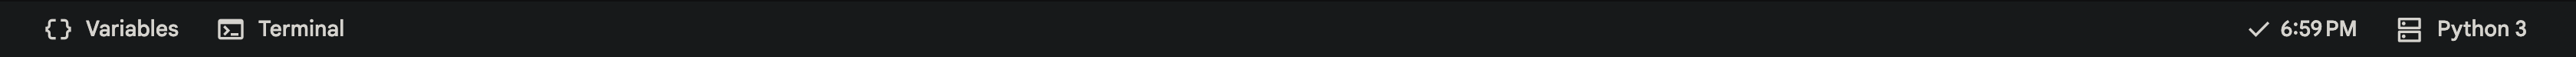

Run this inside and follow the instructions:


```Shell
wine /content/moresampler/moresampler.exe /content/samples/
```

(if theres any error like failed to query current display settings just ignore it and keep on it will still respond)

# Find my oto (execute this)

In [ ]:
import os
import shutil

source_file = '/content/samples/oto.ini'
destination_dir = '/content/oto/'

os.makedirs(destination_dir, exist_ok=True)

try:
    shutil.copy(source_file, destination_dir)
    print(f"File '{source_file}' copied to '{destination_dir}' successfully. Please check /content/oto/")
except FileNotFoundError:
    print(f"Error: Source file '{source_file}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

# Extra tips

- If you clicked the folder with two dots and don't know where you are, click the three dots next to the folder "content" and you'll be back into where you should be

- Click the folder icon (second-lowest icon) on the sidebar to find the files tap

- If the voicebank isn't working as it should be, try different phonemizers and resamplers, even for the legacy one.